# 🌊 Sea Level Monitoring Pipeline
## Copernicus CDS → Parquet → DuckDB

**Project:** Download, explore, and analyze monthly sea level data

**Tech Stack (via `uv`):**
- `earthkit` - Access Copernicus CDS data
- `xarray` & `pandas` - Data processing
- `pyarrow` - Parquet format
- `matplotlib` - Visualization
- `duckdb` - Data warehouse (local, serverless)

## 📦 Setup: Using `uv` for Package Management

**Before running this notebook, set up your project with `uv`:**

```bash
# Create project directory
mkdir sea-level-monitoring
cd sea-level-monitoring

# Initialize uv project
uv init --python 3.11

# Add dependencies
uv add earthkit cdsapi xarray pandas pyarrow matplotlib numpy duckdb

# Add dev dependencies (jupyter for this notebook)
uv add --dev jupyter ipython

# Activate virtual environment
source .venv/bin/activate  # On Windows: .venv\\Scripts\\activate

# Start Jupyter from the project directory
jupyter notebook
```

**Expected project structure:**
```
sea-level-monitoring/
├── pyproject.toml              # uv project config
├── uv.lock                     # Dependency lock file
├── .venv/                      # Virtual environment
├── sea_level_monitoring.ipynb  # This notebook
└── data/                       # (created by this notebook)
    ├── sea_level_data.nc
    ├── sea_level_data.parquet
    └── sea_level_monitoring.duckdb
```

## 1️⃣ Verify Packages Installed via `uv`

In [1]:
# Verify all packages installed via uv
packages_to_check = {
    'earthkit': 'earthkit.data',
    'cdsapi': 'cdsapi',
    'xarray': 'xarray',
    'pandas': 'pandas',
    'pyarrow': 'pyarrow',
    'matplotlib': 'matplotlib',
    'duckdb': 'duckdb',
    'numpy': 'numpy'
}

print("🔍 Checking installed packages via uv...\n")

all_installed = True
for package_name, import_name in packages_to_check.items():
    try:
        __import__(import_name)
        # Get version
        module = __import__(import_name)
        version = getattr(module, '__version__', 'unknown')
        print(f"✅ {package_name:<15} v{version}")
    except ImportError:
        print(f"❌ {package_name:<15} NOT installed")
        all_installed = False

if all_installed:
    print("\n✅ All packages installed! Ready to proceed.")
else:
    print("\n⚠️  Some packages missing. Run in your project directory:")
    print("   uv add earthkit cdsapi xarray pandas pyarrow matplotlib numpy duckdb")

🔍 Checking installed packages via uv...

✅ earthkit        v0.13.2
✅ cdsapi          vunknown
✅ xarray          v2026.2.0
✅ pandas          v2.3.3
✅ pyarrow         v23.0.1
✅ matplotlib      v3.10.8
✅ duckdb          v1.5.1
✅ numpy           v2.4.4

✅ All packages installed! Ready to proceed.


## 2️⃣ Import Libraries

In [2]:
from datetime import datetime
from pathlib import Path
import zipfile

import catppuccin
import cdsapi
import duckdb
import earthkit.data as ek
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import warnings

warnings.filterwarnings('ignore')

# Set up plotting style
mpl.style.use(catppuccin.PALETTE.macchiato.identifier)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!
📁 Data directory: /home/ludo/Public/Projets_IA/sea-level-monitoring/data/


In [23]:
# Create data directory
data_dir = Path.cwd().parent / 'data'
data_dir.mkdir(exist_ok=True)

# Zip downloaded file
zip_file = data_dir / 'sea_level_data.zip'

# Subfolder with nc extracted files
nc_dir = data_dir / 'nc_files'
nc_dir.mkdir(exist_ok=True)

# Generated images folder
img_dir = Path.cwd().parent / 'img'
img_dir.mkdir(exist_ok=True)

print(f"📁 Data directory: {data_dir.absolute()}/")
print(f"🖼️ Images directory: {img_dir.absolute()}/")

📁 Data directory: /home/ludo/Public/Projets_IA/sea-level-monitoring/data/
🖼️ Images directory: /home/ludo/Public/Projets_IA/sea-level-monitoring/img/


### 📝 Understanding warnings.filterwarnings('ignore')

What does it do?

warnings.filterwarnings('ignore') suppresses non-critical warning messages.

Why? Libraries emit warnings about deprecated features or future changes. These don't break code—they just clutter output.

Is it safe? ✅ Yes! Errors still show up. Only advisory warnings are hidden.

Other options:

warnings.filterwarnings('ignore')    # Hide warnings (our choice)
warnings.filterwarnings('default')   # Show warnings (Python default)
warnings.filterwarnings('error')     # Convert warnings to errors

## 3️⃣ Copernicus CDS API Setup

**Important Setup Steps:**
1. Go to https://cds.climate.copernicus.eu/
2. Create an account & log in
3. Accept the terms and conditions
4. Get your API key from your profile page
5. Create `~/.cdsapirc` file with your credentials:

```
url: https://cds.climate.copernicus.eu/api/v2
key: YOUR_UID:YOUR_API_KEY
```

In [3]:
# Check if CDS API credentials exist
cds_config_path = Path.home() / '.cdsapirc'

print("🔐 Checking Copernicus CDS API credentials...\n")

if cds_config_path.exists():
    print("✅ CDS API credentials found at ~/.cdsapirc")
    print("\n📋 Credentials file exists. You can proceed to download data.")
else:
    print("⚠️  CDS API credentials NOT found.\n")
    print("📋 Setup instructions:")
    print("1. Go to: https://cds.climate.copernicus.eu/")
    print("2. Log in or create an account")
    print("3. Click your profile icon → Accept terms and conditions")
    print("4. Go to: https://cds.climate.copernicus.eu/profile")
    print("5. Copy your UID and API key")
    print("6. Create ~/.cdsapirc with:")
    print("")
    print("   url: https://cds.climate.copernicus.eu/api/v2")
    print("   key: YOUR_UID:YOUR_API_KEY")
    print("")
    print("7. Set file permissions: chmod 600 ~/.cdsapirc")

🔐 Checking Copernicus CDS API credentials...

✅ CDS API credentials found at ~/.cdsapirc

📋 Credentials file exists. You can proceed to download data.


## 4️⃣ Get Sea Level Data

### Download data from Copernicus CDS

https://cds.climate.copernicus.eu/datasets/satellite-sea-level-global?tab=overview

We'll download monthly sea level anomaly data for 2019-2023

In [5]:
dataset_name = 'satellite-sea-level-global'

request_params = {
    'variable': 'monthly_mean',
    # 'year': ['2019', '2020', '2021', '2022', '2023',],
    # 'month': ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12'],
    'year': ['2019',],
    'month': ['01', '02', '03',],
    'version': 'vdt2024',
}

print('📥 Downloading sea level data...\n')
print(f'Dataset: {dataset_name}')
print(f'Period: {min(request_params["year"])}−{min(request_params["month"])}', end=' / ')
print(f'{max(request_params["year"])}−{max(request_params["month"])}')
print(f'Output: {zip_file}')
print('\n⏳ This may take 2-5 minutes...\n')

try:
    client = cdsapi.Client(timeout=120)
    client.retrieve(
        dataset_name,
        request_params,
        target=str(zip_file),
    )
    print('✅ Download complete!')

except Exception as e:
    print(f'❌ Download failed: {type(e).__name__}')
    print(f'Error: {e}')
    print('\nTroubleshooting:')
    print('- Check ~/.cdsapirc exists and has correct format')
    print('- Run: chmod 600 ~/.cdsapirc')
    print('- Check internet connection')
    print('- Try smaller date range first')

if zip_file.exists():
    size_mb = zip_file.stat().st_size / 1024 / 1024
    print(f'\n📁 Zip archive size: {size_mb:.1f} MiB')

📥 Downloading sea level data...

Dataset: satellite-sea-level-global
Period: 2019−01 / 2019−03
Output: /home/ludo/Public/Projets_IA/sea-level-monitoring/data/sea_level_data.zip

⏳ This may take 2-5 minutes...



2026-04-08 15:20:42,310 INFO Request ID is 053870e3-d7b3-45be-8a6b-21b93ac5a499
2026-04-08 15:20:42,380 INFO status has been updated to accepted
2026-04-08 15:20:50,828 INFO status has been updated to running
2026-04-08 15:21:15,094 INFO status has been updated to successful


95ad07353d7df4ed7cbc012cde5a3190.zip:   0%|          | 0.00/7.10M [00:00<?, ?B/s]

✅ Download complete!

📁 Zip archive size: 7.10 MiB


### Extract Zip archive

In [6]:
print('📦 Extraction du ZIP...\n')

try:
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(nc_dir)
    
    # Lister les fichiers .nc
    nc_files = sorted(list(nc_dir.glob('*.nc')))
    print(f'✅ Extraction complétée!')
    print(f'\n📊 Fichiers extraits: {len(nc_files)}')
    for f in nc_files[:5]:  # Afficher les 5 premiers
        print(f'  - {f.name}')
    if len(nc_files) > 5:
        print(f'  ... et {len(nc_files) - 5} autres')
        
except Exception as e:
    print(f'❌ Erreur: {e}')

📦 Extraction du ZIP...

✅ Extraction complétée!

📊 Fichiers extraits: 3
  - dt_global_twosat_phy_l4_201901_vDT2024-M01.nc
  - dt_global_twosat_phy_l4_201902_vDT2024-M01.nc
  - dt_global_twosat_phy_l4_201903_vDT2024-M01.nc


## 5️⃣ Load & Explore the NetCDF Data

### Load & Combine all NC files with `xarray`

In [8]:
# Load the downloaded NetCDF file with xarray
nc_files = sorted(list(nc_dir.glob('*.nc')))

print(f'🔓 Loading {len(nc_files)} NetCDF files…\n')

datasets = []
for nc_file in nc_files:
    try:
        ds = xr.open_dataset(nc_file, engine='netcdf4')
        datasets.append(ds)
        print(f'✅ {nc_file.name}')
    except Exception as e:
        print(f'❌ {nc_file.name}: {e}')

if datasets:
    # Combine every dataset, sorted by time
    print('\n🔀 Combining datasets…')
    ds = xr.concat(datasets, dim='time').sortby('time')
    # print(f'✅ Combined dataset shape: {dict(ds.dims)}')
    # print(f'\n{ds}')
else:
    print('❌ No file loaded')

🔓 Loading 3 NetCDF files…

✅ dt_global_twosat_phy_l4_201901_vDT2024-M01.nc
✅ dt_global_twosat_phy_l4_201902_vDT2024-M01.nc
✅ dt_global_twosat_phy_l4_201903_vDT2024-M01.nc

🔀 Combining datasets…
✅ Combined dataset shape: {'time': 3, 'nv': 2, 'latitude': 720, 'longitude': 1440}

<xarray.Dataset> Size: 50MB
Dimensions:           (time: 3, nv: 2, latitude: 720, longitude: 1440)
Coordinates:
  * time              (time) datetime64[ns] 24B 2019-01-15 2019-02-15 2019-03-15
  * nv                (nv) int32 8B 0 1
  * latitude          (latitude) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * longitude         (longitude) float32 6kB -179.9 -179.6 ... 179.6 179.9
Data variables:
    crs               (time) int32 12B -2147483647 -2147483647 -2147483647
    climatology_bnds  (time, nv) datetime64[ns] 48B 2019-01-01 ... 2019-03-31
    lat_bnds          (time, latitude, nv) float32 17kB -90.0 -89.75 ... 90.0
    lon_bnds          (time, longitude, nv) float32 35kB -180.0 -179.8 ... 180.0
    sla   

### Dataset info

In [9]:
print("📊 Full Dataset:")
print("="*70)
print(ds)
print("="*70)

print("\n📋 Summary Info:")
print(f"  • Dimensions: {dict(ds.dims)}")
print(f"  • Variables: {list(ds.data_vars)}")
print(f"  • Coordinates: {list(ds.coords)}")
print(f"  • Data type: {ds.data_vars[list(ds.data_vars)[0]].dtype}")

📊 Full Dataset:
<xarray.Dataset> Size: 50MB
Dimensions:           (time: 3, nv: 2, latitude: 720, longitude: 1440)
Coordinates:
  * time              (time) datetime64[ns] 24B 2019-01-15 2019-02-15 2019-03-15
  * nv                (nv) int32 8B 0 1
  * latitude          (latitude) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * longitude         (longitude) float32 6kB -179.9 -179.6 ... 179.6 179.9
Data variables:
    crs               (time) int32 12B -2147483647 -2147483647 -2147483647
    climatology_bnds  (time, nv) datetime64[ns] 48B 2019-01-01 ... 2019-03-31
    lat_bnds          (time, latitude, nv) float32 17kB -90.0 -89.75 ... 90.0
    lon_bnds          (time, longitude, nv) float32 35kB -180.0 -179.8 ... 180.0
    sla               (time, latitude, longitude) float64 25MB nan nan ... nan
    eke               (time, latitude, longitude) float64 25MB nan nan ... nan
Attributes: (12/41)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Datas

## 6️⃣ Data Exploration & Quality Checks

In [18]:
# Data quality analysis
print("🔍 Data Quality Check:")
print("="*70)

for var in ds.data_vars:
    total_values = ds[var].size
    missing_count = int(ds[var].isnull().sum().values)
    missing_pct = (missing_count / total_values) * 100

    print(f"\n📊 Variable: {var}")
    print(f"   Total values: {total_values:,}")
    print(f"   Missing values: {missing_count:,} ({missing_pct:.2f}%)")
    print(f"   Data type: {ds[var].dtype}")

print("\n" + "="*70)
print("📈 Basic Statistics:")
print("="*70)

for var in ds.data_vars:
    print(f"−−−−−−−−−\n{var}:")
    # as `describe()` in Pandas
    data = ds[var].values.flatten()
    data = data[~np.isnan(data)]  # Remove NaNs
    try:
        print(f'  Min: {np.min(data):.6f}')
        print(f'  Max: {np.max(data):.6f}')
        print(f'  Mean: {np.mean(data):.6f}')
        print(f'  Std: {np.std(data):.6f}')
        print(f'  Median: {np.median(data):.6f}')
    except:  # str/timestamps raise exceptions, ignore them
        pass

🔍 Data Quality Check:

📊 Variable: crs
   Total values: 3
   Missing values: 0 (0.00%)
   Data type: int32

📊 Variable: climatology_bnds
   Total values: 6
   Missing values: 0 (0.00%)
   Data type: datetime64[ns]

📊 Variable: lat_bnds
   Total values: 4,320
   Missing values: 0 (0.00%)
   Data type: float32

📊 Variable: lon_bnds
   Total values: 8,640
   Missing values: 0 (0.00%)
   Data type: float32

📊 Variable: sla
   Total values: 3,110,400
   Missing values: 1,343,554 (43.20%)
   Data type: float64

📊 Variable: eke
   Total values: 3,110,400
   Missing values: 1,343,574 (43.20%)
   Data type: float64

📈 Basic Statistics:
−−−−−−−−−
crs:
  Min: -2147483647.000000
  Max: -2147483647.000000
  Mean: -2147483647.000000
  Std: 0.000000
  Median: -2147483647.000000
−−−−−−−−−
climatology_bnds:
−−−−−−−−−
lat_bnds:
  Min: -90.000000
  Max: 90.000000
  Mean: 0.000000
  Std: 51.961624
  Median: 0.000000
−−−−−−−−−
lon_bnds:
  Min: -180.000000
  Max: 180.000000
  Mean: 0.000000
  Std: 103.92310

## 7️⃣ Visualization

In [21]:
%matplotlib inline

📈 Generating global sea level anomaly map...



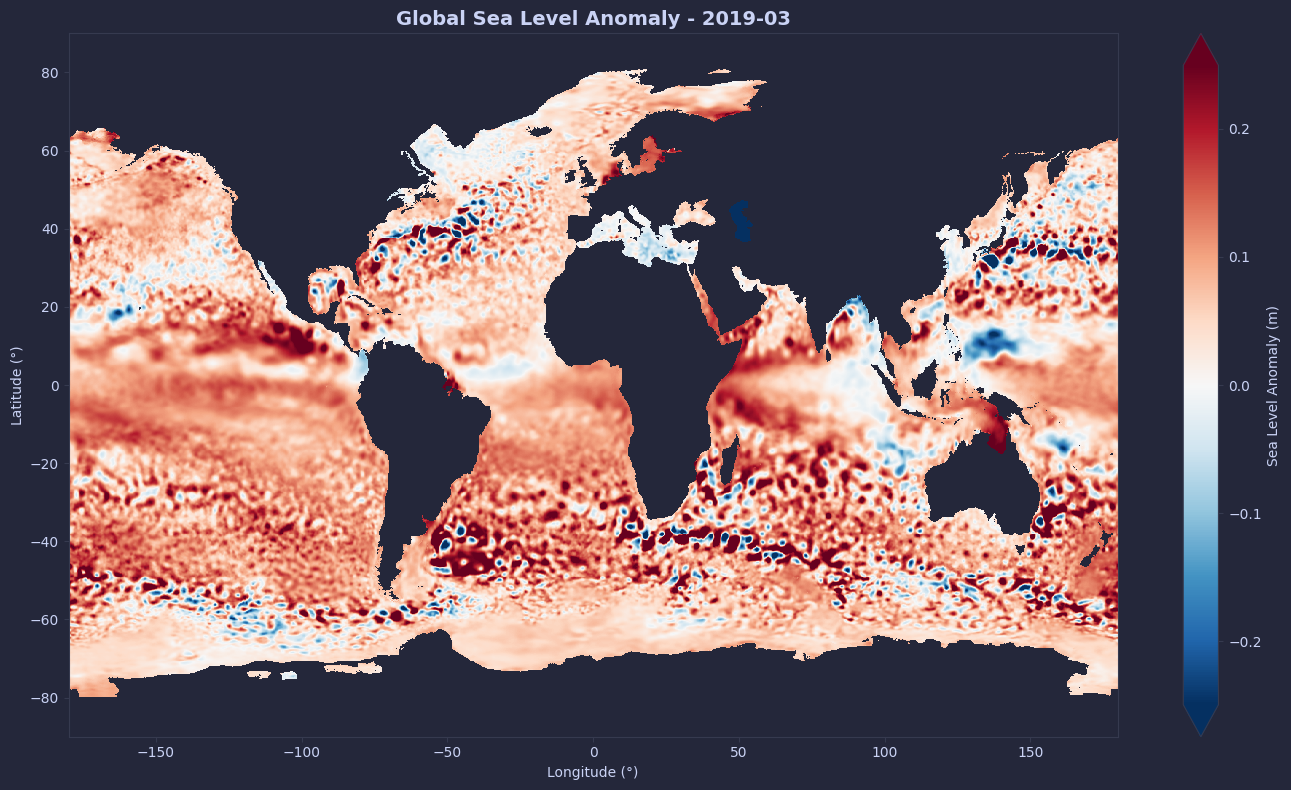

✅ Map saved to: /home/ludo/Public/Projets_IA/sea-level-monitoring/img/sea_level_map.png


In [24]:
# Visualize latest sea level anomaly map
if 'sla' in ds.data_vars:
    print("📈 Generating global sea level anomaly map...\n")

    # Get the latest time slice
    latest_sla = ds['sla'].isel(time=-1)

    fig, ax = plt.subplots(figsize=(14, 8))

    # Plot with diverging colormap (red = high, blue = low)
    im = latest_sla.plot(
        ax=ax,
        cmap='RdBu_r',
        cbar_kwargs={'label': 'Sea Level Anomaly (m)'},
        robust=True  # Use robust percentiles for better color scaling
    )

    time_val = pd.Timestamp(latest_sla.time.values).strftime('%Y-%m')
    ax.set_title(f'Global Sea Level Anomaly - {time_val}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('Latitude (°)')

    plt.tight_layout()

    map_file = img_dir / 'sea_level_map.png'
    plt.savefig(map_file, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Map saved to: {map_file}")

📈 Generating time series plot...



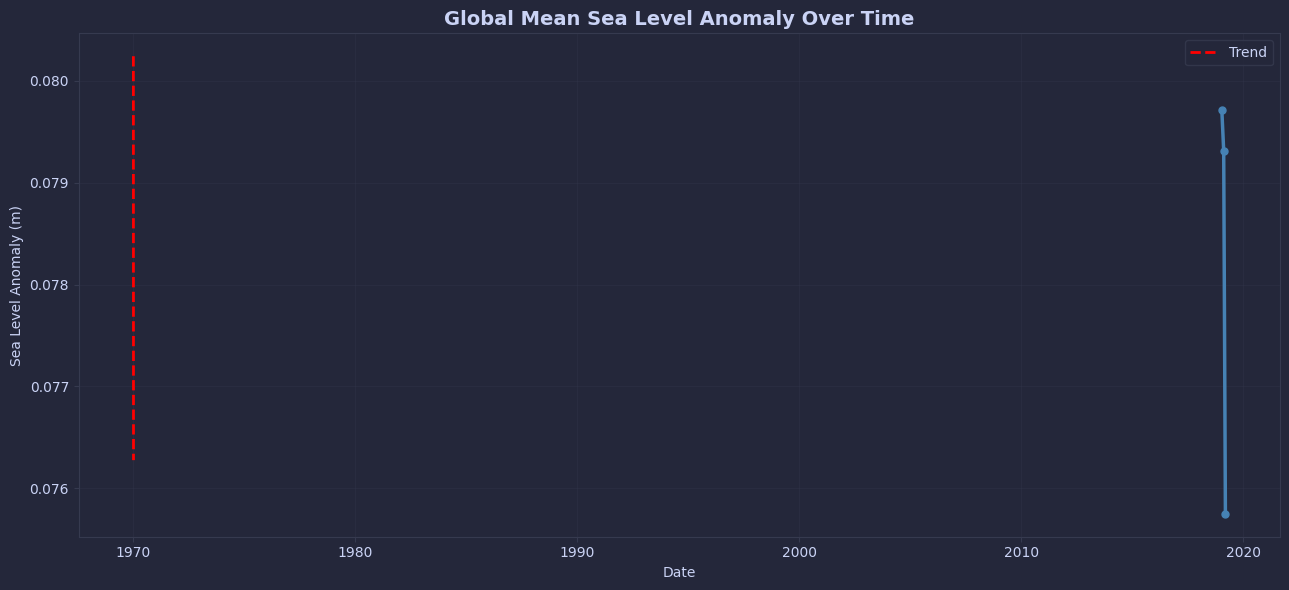

✅ Time series plot saved to: /home/ludo/Public/Projets_IA/sea-level-monitoring/img/sea_level_timeseries.png


In [25]:
# Time series: Global mean sea level anomaly
if 'sla' in ds.data_vars:
    print("📈 Generating time series plot...\n")

    # Calculate global spatial mean
    global_mean_sla = ds['sla'].mean(dim=['longitude', 'latitude'])

    fig, ax = plt.subplots(figsize=(13, 6))

    # Plot with markers
    global_mean_sla.plot(
        ax=ax,
        linewidth=2.5,
        marker='o',
        markersize=5,
        color='steelblue'
    )

    # Add trend line
    z = np.polyfit(range(len(global_mean_sla)), global_mean_sla.values, 1)
    p = np.poly1d(z)
    ax.plot(range(len(global_mean_sla)), p(range(len(global_mean_sla))), 
            "r--", linewidth=2, label='Trend')

    ax.set_title('Global Mean Sea Level Anomaly Over Time', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Sea Level Anomaly (m)')
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()

    ts_file = img_dir / 'sea_level_timeseries.png'
    plt.savefig(ts_file, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Time series plot saved to: {ts_file}")

## 8️⃣ Transform to Parquet Format

In [26]:
# Convert xarray Dataset to pandas DataFrame → Parquet
print("🔄 Transforming NetCDF → Parquet…\n")

if 'sla' in ds.data_vars:
    # Stack spatial dimensions and convert to DataFrame
    sla_data = ds['sla'].to_pandas()
    
    # Reset index and melt into long format
    df = sla_data.reset_index()
    df_melted = df.melt(
        id_vars=['time'],
        var_name='location',
        value_name='sea_level_anomaly_m'
    )
    
    # Extract latitude and longitude from location tuple
    df_melted['latitude'] = df_melted['location'].apply(
        lambda x: float(str(x).split(',')[0].replace('(', ''))
    )
    df_melted['longitude'] = df_melted['location'].apply(
        lambda x: float(str(x).split(',')[1].replace(')', ''))
    )
    
    # Clean up and add datetime columns
    df_melted = df_melted.drop('location', axis=1)
    df_melted['timestamp'] = pd.to_datetime(df_melted['time'])
    df_melted['year'] = df_melted['timestamp'].dt.year
    df_melted['month'] = df_melted['timestamp'].dt.month
    df_melted['date'] = df_melted['timestamp'].dt.date
    
    # Remove NaN values (important for clean data)
    df_melted = df_melted.dropna(subset=['sea_level_anomaly_m'])
    
    # Reorder columns for clarity
    df_melted = df_melted[[
        'timestamp', 'date', 'year', 'month',
        'latitude', 'longitude',
        'sea_level_anomaly_m'
    ]]
    
    print(f"📊 Transformed DataFrame:")
    print(f"   Shape: {df_melted.shape}")
    print(f"   Rows: {len(df_melted):,}")
    print(f"   Columns: {list(df_melted.columns)}")
    print(f"\n📋 Sample data:")
    print(df_melted.head(10))
    
    # Save to Parquet with Snappy compression
    parquet_file = data_dir / 'sea_level_data.parquet'
    df_melted.to_parquet(
        parquet_file,
        compression='snappy',
        index=False,
        engine='pyarrow'
    )
    
    print(f"\n✅ Parquet file created!")
    print(f"   Path: {parquet_file}")
    print(f"   Size: {parquet_file.stat().st_size / 1024 / 1024:.2f} MB")
    print(f"   Compression: Snappy")

🔄 Transforming NetCDF → Parquet…



ValueError: Cannot convert arrays with 3 dimensions into pandas objects. Requires 2 or fewer dimensions.

## 9️⃣ Verify Parquet File

In [ ]:
# Read and verify the parquet file
parquet_file = data_dir / 'sea_level_data.parquet'

if parquet_file.exists():
    print("✅ Parquet file verification:\n")
    
    # Read parquet file
    df_verify = pd.read_parquet(parquet_file)
    
    print(f"📊 Shape: {df_verify.shape}")
    print(f"\n📋 Data types:")
    print(df_verify.dtypes)
    print(f"\n🔢 First 5 rows:")
    print(df_verify.head())
    print(f"\n📊 Summary statistics:")
    print(df_verify[['latitude', 'longitude', 'sea_level_anomaly_m']].describe())
    print(f"\n📅 Date range:")
    print(f"   From: {df_verify['date'].min()}")
    print(f"   To: {df_verify['date'].max()}")
else:
    print(f"❌ File not found: {parquet_file}")

## 🔟 Load into DuckDB (Data Warehouse)

**DuckDB Benefits:**
- ✅ Zero setup - embedded SQLite-like database
- ✅ Fast - optimized for OLAP queries
- ✅ Local - no server needed
- ✅ SQL support - use standard SQL
- ✅ Parquet native - direct read/write

In [ ]:
# Initialize DuckDB database
db_file = data_dir / 'sea_level_monitoring.duckdb'

print(f"🗄️  Initializing DuckDB database...\n")

# Connect to DuckDB (creates database if doesn't exist)
conn = duckdb.connect(str(db_file))

print(f"✅ Connected to DuckDB")
print(f"   Database: {db_file}")
print(f"   File size: {db_file.stat().st_size / 1024 / 1024:.2f} MB" if db_file.exists() else "   (new database)")

In [ ]:
# Create table from Parquet file
print("📥 Loading Parquet data into DuckDB...\n")

try:
    # SQL command to create table from parquet
    create_table_sql = f"""
    CREATE TABLE sea_level_monthly AS
    SELECT * FROM read_parquet('{parquet_file}')
    """
    
    conn.execute(create_table_sql)
    
    # Get table info
    result = conn.execute("SELECT COUNT(*) as row_count FROM sea_level_monthly").fetchall()
    row_count = result[0][0]
    
    print(f"✅ Table created: sea_level_monthly")
    print(f"   Rows: {row_count:,}")
    print(f"\n📊 Table schema:")
    schema = conn.execute("DESCRIBE sea_level_monthly").fetchall()
    for col_name, col_type, *rest in schema:
        print(f"   • {col_name}: {col_type}")
        
except Exception as e:
    print(f"⚠️  Table might already exist. Recreating...")
    conn.execute("DROP TABLE IF EXISTS sea_level_monthly")
    create_table_sql = f"""
    CREATE TABLE sea_level_monthly AS
    SELECT * FROM read_parquet('{parquet_file}')
    """
    conn.execute(create_table_sql)
    print(f"✅ Table recreated: sea_level_monthly")

## 1️⃣1️⃣ Query Examples - DuckDB SQL

In [ ]:
# Example 1: Global statistics by year
print("📊 Query 1: Global Mean Sea Level Anomaly by Year\n")

query1 = """
SELECT
    year,
    COUNT(*) as measurements,
    AVG(sea_level_anomaly_m) as mean_anomaly_m,
    MIN(sea_level_anomaly_m) as min_anomaly_m,
    MAX(sea_level_anomaly_m) as max_anomaly_m,
    STDDEV(sea_level_anomaly_m) as std_dev_m
FROM sea_level_monthly
GROUP BY year
ORDER BY year
"""

result1 = conn.execute(query1).fetchall()
df_result1 = conn.execute(query1).df()
print(df_result1.to_string(index=False))

In [ ]:
# Example 2: Highest and lowest sea level anomaly locations
print("\n📊 Query 2: Locations with Extreme Sea Level Anomalies (Latest Month)\n")

query2_high = """
SELECT
    'Highest' as anomaly_type,
    latitude,
    longitude,
    sea_level_anomaly_m,
    timestamp
FROM sea_level_monthly
WHERE timestamp = (SELECT MAX(timestamp) FROM sea_level_monthly)
ORDER BY sea_level_anomaly_m DESC
LIMIT 5
UNION ALL
SELECT
    'Lowest' as anomaly_type,
    latitude,
    longitude,
    sea_level_anomaly_m,
    timestamp
FROM sea_level_monthly
WHERE timestamp = (SELECT MAX(timestamp) FROM sea_level_monthly)
ORDER BY sea_level_anomaly_m ASC
LIMIT 5
"""

df_result2 = conn.execute(query2_high).df()
print(df_result2.to_string(index=False))

In [ ]:
# Example 3: Regional analysis (choose a region)
print("\n📊 Query 3: Mediterranean Sea Region (Sample)\n")

# Mediterranean bounds: roughly 30-45°N, -6-42°E
query3 = """
SELECT
    timestamp,
    ROUND(AVG(sea_level_anomaly_m), 4) as mean_anomaly_m,
    COUNT(*) as grid_points
FROM sea_level_monthly
WHERE latitude BETWEEN 30 AND 45
  AND longitude BETWEEN -6 AND 42
GROUP BY timestamp
ORDER BY timestamp DESC
LIMIT 12
"""

df_result3 = conn.execute(query3).df()
print(df_result3.to_string(index=False))

## 1️⃣2️⃣ Summary & Next Steps

### ✅ What We've Built:

**Data Pipeline:**
```
Copernicus CDS (API)
        ↓
    earthkit download
        ↓
    NetCDF file (raw data)
        ↓
    xarray → pandas transformation
        ↓
    Parquet file (compressed)
        ↓
    DuckDB table (queryable)
        ↓
   SQL Analysis & Visualization
```

### 📁 Project Structure Created:
```
sea-level-monitoring/
├── pyproject.toml                      # uv project config
├── uv.lock                             # Locked dependencies
├── sea_level_monitoring.ipynb          # This notebook
└── data/
    ├── sea_level_data.nc               # Raw NetCDF from CDS
    ├── sea_level_data.parquet          # Transformed data
    ├── sea_level_monitoring.duckdb     # Local database
    ├── sea_level_map.png               # Visualization
    └── sea_level_timeseries.png        # Time series plot
```

### 🚀 Phase 2: Machine Learning (Next Steps)

1. **Exploratory Data Analysis (EDA)**
   - Seasonal patterns, anomalies
   - Regional differences
   - Correlation analysis

2. **Feature Engineering**
   - Lag features (t-1, t-3, t-6, t-12)
   - Rolling averages
   - Seasonal decomposition
   - Trend extraction

3. **Time Series Forecasting**
   - ARIMA/SARIMA models
   - Prophet (Facebook)
   - LSTM neural networks
   - Predict next 6-12 months

4. **Model Evaluation**
   - Cross-validation
   - RMSE, MAE, MAPE metrics
   - Backtesting

### 📚 Useful Resources:
- [Copernicus CDS API](https://cds.climate.copernicus.eu/how-to-api)
- [earthkit Documentation](https://earthkit.readthedocs.io/)
- [DuckDB SQL Reference](https://duckdb.org/docs/sql/introduction.html)
- [xarray Docs](http://tutorial.xarray.org/)
- [uv Package Manager](https://docs.astral.sh/uv/)

### ✨ Pro Tips:
- **Keep uv.lock in version control** for reproducibility
- **Use DuckDB for exploratory queries** - no setup needed
- **Export to PostgreSQL when ready** for production
- **Automate downloads** with cron jobs or Airflow in Phase 3

In [ ]:
# Final status check
print("\n" + "="*70)
print("🎉 PROJECT STATUS")
print("="*70)

files_status = [
    ('NetCDF raw data', data_dir / 'sea_level_data.nc'),
    ('Parquet transformed', data_dir / 'sea_level_data.parquet'),
    ('DuckDB database', data_dir / 'sea_level_monitoring.duckdb'),
    ('Map visualization', data_dir / 'sea_level_map.png'),
    ('Time series plot', data_dir / 'sea_level_timeseries.png'),
]

for name, path in files_status:
    if path.exists():
        size = path.stat().st_size / 1024
        print(f"✅ {name:<25} {size:>10.2f} KB")
    else:
        print(f"⏭️  {name:<25} (not yet created)")

print("\n" + "="*70)
print("Ready for Phase 2: Machine Learning! 🚀")
print("="*70)